# CBE 60546 Examples

See https://docs.scipy.org/doc/scipy/reference/constants.html for list of scipy constants

In [2]:
import scipy.constants as const 

## Example 1 - Flow rate calculation

Air is 80% N2 and 20% O2 (mol/mol). A mass flow controller delivers 1 g/s of dry air to a reactor at 298 K and 1 bar. What are the molar flow rates of N2, O2, and the total volumetric flow rate?

In [3]:
T = 298 ; P =1.0e5 # K, Pa

In [4]:
yN2 = 0.8; yO2=0.2

In [5]:
MWN2 = 28; MWO2 = 32

In [6]:
MWair = yN2*MWN2 + yO2*MWO2 # g/mol

In [7]:
massflowrate = 1 # g air /s

In [8]:
FN2 = massflowrate * MWair * yN2 # mol/s

In [9]:
FO2 = massflowrate * MWair * yO2 # mol/S

In [10]:
print("N2, O2 molar flow rates = {0:6.2f} and {1:6.2f} mol/s".format(FN2,FO2))

N2, O2 molar flow rates =  23.04 and   5.76 mol/s


In [11]:
Vdotair = (FN2 + FO2) * const.gas_constant * T / P

In [12]:
print("Volumetric flow rate = {0:8.3f} m3/s".format(Vdotair))

Volumetric flow rate =    0.714 m3/s


## Example 2 - Integrating rate laws
A + B -> C, rate = k CA CB. Integrate and plot concentrations vs time.

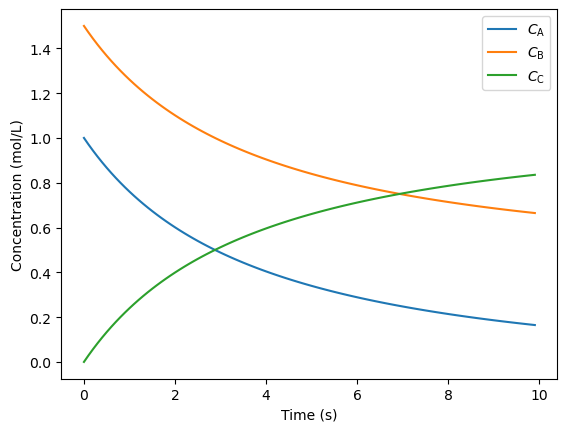

In [13]:
import numpy as np               #this lets up handles arrays of data
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp

def dCdt(C,t,k):
    dC_Adt = -k*C[0]*C[1]     # A + B -> C;  r = k CA CB
    dC_Bdt = -k*C[0]*C[1]
    dC_Cdt =  k*C[0]*C[1]
    dCdt = [dC_Adt,dC_Bdt,dC_Cdt] 
    return dCdt

# initialize concentrations
C_0 = [1., 1.5, 0.]

# initialize k's
k = 0.2

# Range of time to solve over
t = np.arange(0,10,0.1) 

p = (k,) # turn parameters into a tuple
# Solve two ODEs with odeint
C = odeint(dCdt,C_0,t,p)

C_A = C.transpose()[0] # Get C_A from C
C_B = C.transpose()[1] # Get C_B from C
C_C = C.transpose()[2]
plt.figure()
plt.plot(t,C_A,'-',label=r'$C_{\rm A}$')
plt.plot(t,C_B,'-',label=r'$C_{\rm B}$')
plt.plot(t,C_C,'-',label=r'$C_{\rm C}$')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.legend()

## Example 3 - Extracting kinetics from concentration vs time data
m-xylene + Br2 -> Br-m-xylene with an I2 catalyst. Reaction is run at 17 C in xylene solvent and the concentration of Br2 observed vs time. What is the rate order?

### First plot experimental data

Text(0, 0.5, 'Concentration (mol/L)')

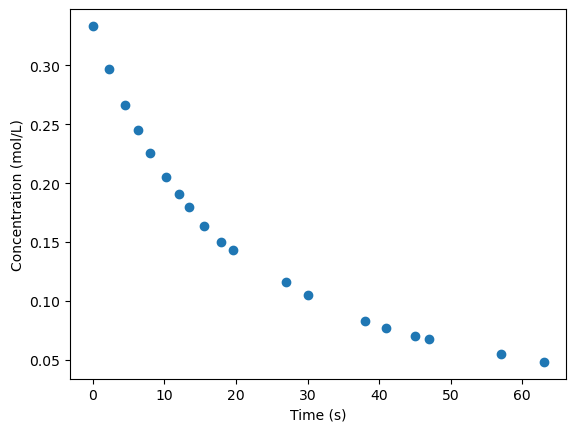

In [14]:
import numpy as np               #this lets up handles arrays of data
import matplotlib.pyplot as plt

# Experimental data:
t = np.array([0.00, 2.25, 4.50, 6.33, 8.00, 10.25, 12.00, 13.50, 15.60, 17.85, 19.60, 27.00, 30.00, 38.00, 41.00, 45.00, 47.00, 57.00, 63.00])

C_Br2 = np.array([0.3335, 0.2965, 0.2660, 0.2450, 0.2255, 0.2050, 0.1910, 0.1794, 0.1632, 0.1500, 0.1429, 0.1160, 0.1053, 0.0830, 0.0767, 0.0705, 0.0678, 0.0553, 0.0482])

plt.figure()
plt.plot(t,C_Br2,'o')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')

### Test whether reactions is first order in Br2 - it isn't!

Text(0.5, 1.0, 'Decidedly not a line!')

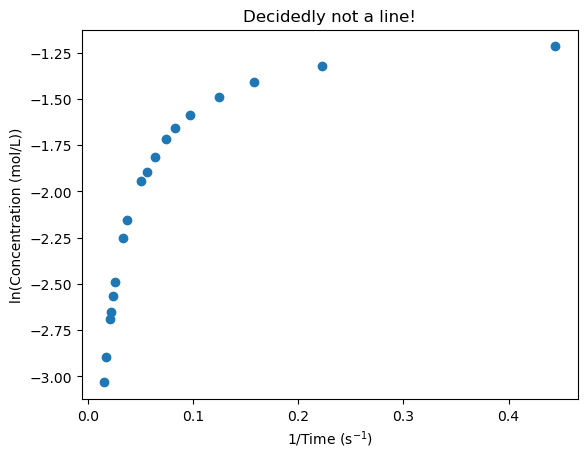

In [15]:
# If first order, ln C vs 1/t should be linear. Remember to remove t=0 data point
lnC_Br2 = np.log(C_Br2[1:])
Inv_t = 1/t[1:]
plt.figure()
plt.plot(Inv_t, lnC_Br2,'o')
plt.xlabel('1/Time (s$^{-1}$)')
plt.ylabel('ln(Concentration (mol/L))')
plt.title('Decidedly not a line!')

### Use finite difference to extract rates

Text(0.5, 1.0, 'Rate of Br2 disappearance vs concentration')

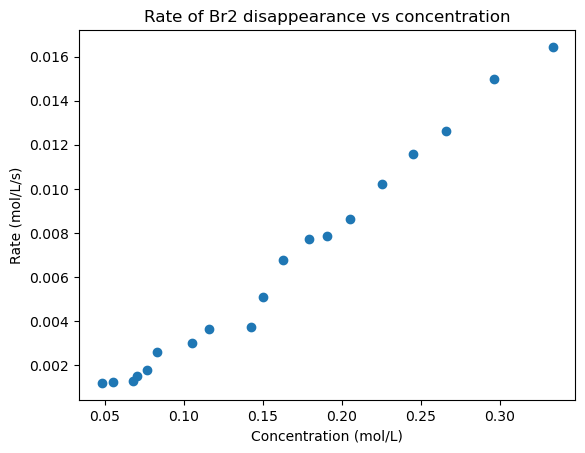

In [16]:
grad_t = np.gradient(t)            # second order approximation to gradient, allowing for unequal step size
grad_C = np.gradient(C_Br2)
rate = -np.divide(grad_C,grad_t)

plt.figure()
plt.plot(C_Br2,rate,'o')
plt.xlabel('Concentration (mol/L)')
plt.ylabel('Rate (mol/L/s)')
plt.title('Rate of Br2 disappearance vs concentration')

### Test whether data fits a power law model

k = 0.085277, alpha=1.450860


Text(0.5, 1.0, 'Observed and modeled rate of Br2 disappearance')

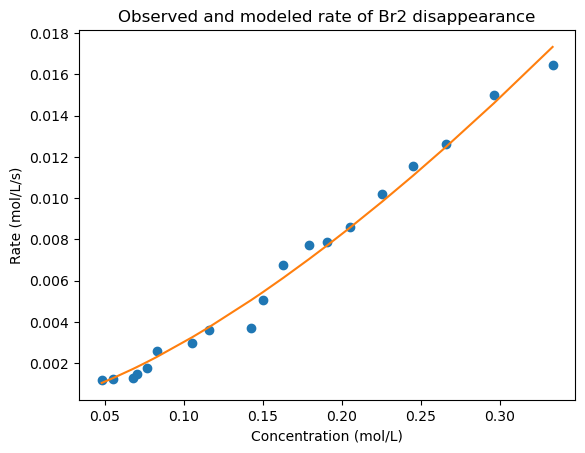

In [17]:
from scipy.optimize import curve_fit

# define rate model with unknown k and alpha
def rate_model(x, k, alpha):
    return k*x**alpha

# attempt to fit rate vs C_Br2 data to differential model
popt, pcov = curve_fit(rate_model, C_Br2, rate )

print('k = {0:f}, alpha={1:f}'.format(popt[0],popt[1]))

model_prediction = rate_model(C_Br2,popt[0],popt[1])

plt.figure()
plt.plot(C_Br2,rate,'o')
plt.plot(C_Br2,model_prediction,'-')
plt.xlabel('Concentration (mol/L)')
plt.ylabel('Rate (mol/L/s)')
plt.title('Observed and modeled rate of Br2 disappearance')

### Plot difference between model and fit. Is it random?

Mean square error = 2.4942019231742504e-07


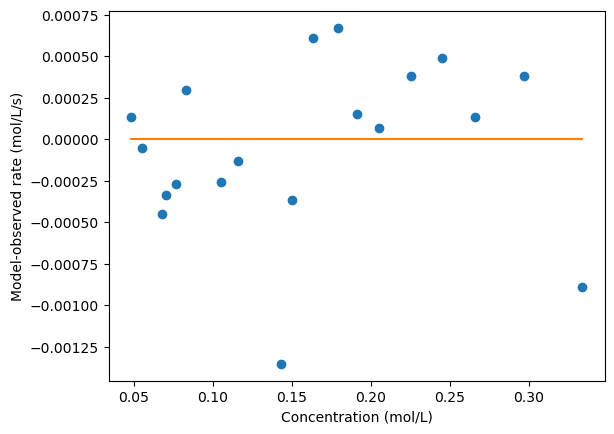

In [18]:
difference_array = np.subtract(rate, model_prediction)
squared_array = np.square(difference_array)
mse = squared_array.mean()
print('Mean square error = {}'.format(mse))
plt.figure()
plt.plot(C_Br2,difference_array,'o')
plt.xlabel('Concentration (mol/L)')
plt.ylabel('Model-observed rate (mol/L/s)')
plt.plot([C_Br2[0],C_Br2[-1]],[0,0],'-')


### Test whether a 3/2 order model would fit the data. First figure out the integrated rate law

In [19]:
from sympy import Function, Eq, dsolve, Symbol
# 1. Define the symbolic variables
time = Symbol('time'); kconst = Symbol('kconst')
Conc = Function('Conc')

# 2. Define the differential equation
# y(x).diff(x) represents the derivative dy/dx
# The Eq() function sets the left side equal to the right side (0 in this case)
equation = Eq(Conc(time).diff(time), -kconst*Conc(time)**(3/2))

print("Original Equation:")
display(equation)

# 3. Solve the differential equation using dsolve()
solution = dsolve(equation, Conc(time))

print("\nSymbolic Solution:")
display(solution)
print('4/C1**2 must be C0, or C1 = 2/C0**0.5')

Original Equation:


Eq(Derivative(Conc(time), time), -kconst*Conc(time)**1.5)


Symbolic Solution:


Eq(Conc(time), 4/(C1**2 - 2*C1*kconst*time + kconst**2*time**2))

4/C1**2 must be C0, or C1 = 2/C0**0.5


### Fit data to integral model

k = 1.450860 1/s 1/M^1/2


Text(0, 0.5, 'Concentration (mol/L)')

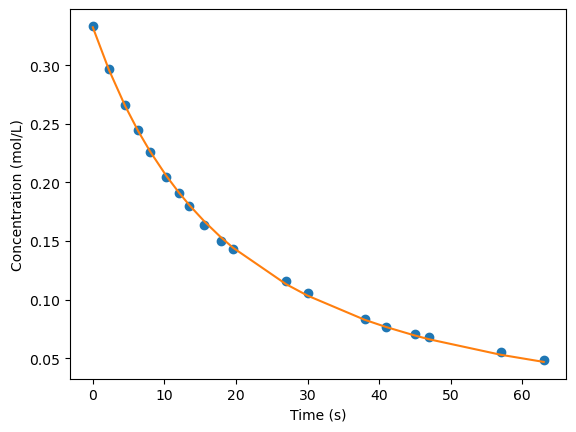

In [20]:
def integral(t, C0, k):
    return (4*C0/(2+k*C0**0.5*t))**2

popt1, pcov1 = curve_fit(integral, t, C_Br2)
print('k = {0:f} 1/s 1/M^1/2'.format(popt[1]))

integral_model = integral(t, popt1[0], popt1[1])

plt.figure()
plt.plot(t,C_Br2,'o')
plt.plot(t,integral_model,'-')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')